# LISA TDI response: analytic fit vs numerical sky average

The `response` function in `fast_lisa_subtraction.simulation.response` supports two methods:

- **`method="analytic"`** (default): the analytical fits of Sec 2.3 of [arXiv:2009.11845](https://arxiv.org/abs/2009.11845)
  for the A, E, T channels, and $\langle|F_X|^2\rangle \simeq 16 \cdot \frac{3}{20}\frac{1}{1+0.6\,\omega^2}$
  ([arXiv:2108.01167](https://arxiv.org/abs/2108.01167)) for X, Y, Z.
- **`method="numerical"`**: the semi-analytic sky- and polarization-averaged response of
  [arXiv:2108.01167](https://arxiv.org/abs/2108.01167): the Michelson responses $F_{X,Y,Z}$ are built from the
  single-arm transfer functions $\Psi_{rs}$ and averaged over sky location and polarization angle,

$$
\langle |F_{\rm ch}|^2 \rangle = \frac{1}{8\pi^2}\int_0^{2\pi}\!\! d\psi \int_0^{2\pi}\!\! d\lambda \int_{-\pi/2}^{\pi/2}\!\! d\beta\, \cos\beta\, |F^{+}_{\rm ch}|^2,
\qquad
\mathcal{R}_{\rm ch}(f) = \omega^2 \sin^2\!\omega \, \langle |F_{\rm ch}|^2 \rangle \times
\begin{cases} 1 & \text{TDI 1.5}\\ 4\sin^2 2\omega & \text{TDI 2.0}\end{cases}
$$

with $\omega = 2\pi f L/c$. By default `method="numerical"` reads precomputed $\langle |F_{\rm ch}|^2 \rangle$
tables (generated once by `scripts/generate_response_tables.py`) and interpolates them with a cubic spline in
log-log space, so it is as fast as the analytic fits. Passing `from_file=False` recomputes the sky integral on
the fly with `sky_averaged_antenna_power`, either with Gauss–Legendre quadrature (`integrator="leggauss"`,
$\psi$-average done analytically) or with the full `scipy.integrate.tplquad` triple integral (slower,
useful as a cross-check).

> **Convention warning**: for A and E the arXiv:2009.11845 analytic fit is a factor of **2 larger** than the
> simulation-validated convention of arXiv:2108.01167 at low frequency ($\langle|F_{A,E}|^2\rangle \to 7.2$ vs $3.6$),
> due to a different polarization normalization of $S_h$. The X-channel numerical response reproduces the
> arXiv:2108.01167 reference values (validated against LISACode) to machine precision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fast_lisa_subtraction.simulation.response import response, sky_averaged_antenna_power

f = np.logspace(-4, 0, 300)  # Hz
channels = ["X", "A", "T"]
colors = {"X": "#0173B2", "A": "#DE8F05", "T": "#029E73"}  # colorblind-safe

In [2]:
R_num = {ch: response(f, ch, tdi2=True, method="numerical") for ch in channels}
R_ana = {ch: response(f, ch, tdi2=True, method="analytic")  for ch in channels}

[INFO] - Substituting symbol R from STIXNonUnicode


[INFO] - Substituting symbol R from STIXNonUnicode


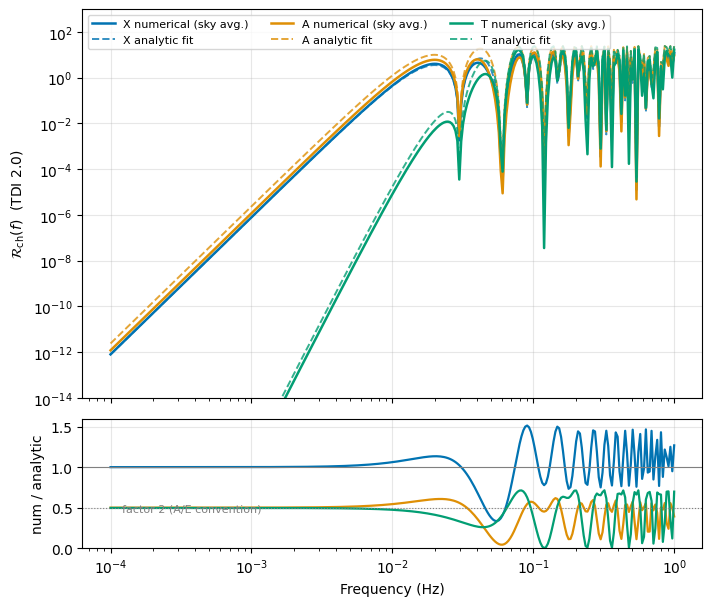

In [3]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

for ch in channels:
    ax.loglog(f, R_num[ch], color=colors[ch], lw=1.8, label=f"{ch} numerical (sky avg.)")
    ax.loglog(f, R_ana[ch], color=colors[ch], lw=1.4, ls="--", alpha=0.8, label=f"{ch} analytic fit")
    axr.semilogx(f, R_num[ch]/R_ana[ch], color=colors[ch], lw=1.6)

ax.set_ylabel(r"$\mathcal{R}_{\rm ch}(f)$  (TDI 2.0)")
ax.set_ylim(1e-14, 1e3)
ax.legend(ncol=3, fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

axr.axhline(1, color="gray", lw=0.8)
axr.axhline(0.5, color="gray", lw=0.8, ls=":")
axr.set_ylabel("num / analytic")
axr.set_xlabel("Frequency (Hz)")
axr.set_ylim(0, 1.6)
axr.grid(alpha=0.3)
axr.text(1.2e-4, 0.55, "factor 2 (A/E convention)", fontsize=8, color="gray", va="top")

plt.show()

## Low-frequency limits

Sanity check of $\langle|F_{\rm ch}|^2\rangle$ at $f \to 0$: X, Y, Z $\to 16\times 3/20 = 2.4$;
A, E $\to 3.6$ (i.e. $\tfrac{3}{2}$ of X, since $\langle F_X F_Z^*\rangle = -\tfrac{1}{2}\langle|F_X|^2\rangle$);
T $\to 0$. Note that the sum rule $\langle|F_A|^2+|F_E|^2+|F_T|^2\rangle = 3\,\langle|F_X|^2\rangle$ holds
exactly (A, E, T is a unitary transformation of X, Y, Z).

In [4]:
f_low = np.array([1e-5])
for ch in ["X", "Y", "Z", "A", "E", "T"]:
    val = sky_averaged_antenna_power(f_low, channel=ch)[0]
    print(f"<|F_{ch}|^2>(f->0) = {val:.6f}")

<|F_X|^2>(f->0) = 2.400000
<|F_Y|^2>(f->0) = 2.400000
<|F_Z|^2>(f->0) = 2.400000
<|F_A|^2>(f->0) = 3.600000
<|F_E|^2>(f->0) = 3.600000
<|F_T|^2>(f->0) = 0.000000


## Cross-check: fast quadrature vs `scipy.integrate.tplquad`

The default `leggauss` integrator agrees with the full `tplquad` triple integral to machine precision
(the `scipy` integrator gets slow at high frequency, so we only check a few points here).

In [5]:
for fi in [1e-4, 1e-3, 1e-2]:
    v_quad  = sky_averaged_antenna_power(fi, channel="X", integrator="scipy")[0]
    v_gauss = sky_averaged_antenna_power(fi, channel="X", integrator="leggauss")[0]
    print(f"f = {fi:.0e} Hz   tplquad = {v_quad:.10f}   leggauss = {v_gauss:.10f}   "
          f"rel. diff = {abs(v_quad - v_gauss)/v_quad:.2e}")

f = 1e-04 Hz   tplquad = 2.3999779065   leggauss = 2.3999779065   rel. diff = 3.70e-16


f = 1e-03 Hz   tplquad = 2.3977914909   leggauss = 2.3977914909   rel. diff = 1.85e-16


f = 1e-02 Hz   tplquad = 2.1873694465   leggauss = 2.1873694465   rel. diff = 2.03e-16


## Validation against the reference tables of arXiv:2108.01167

**Table 2** (response of TDI $X_{2.0}$): the entries at $10^{-4}$–$10^{-1}$ Hz are the paper's exact
semi-analytic values and our implementation reproduces them to the printed precision. (The 1 Hz entry of
Table 2 is the *analytic approximation*, not the exact value, so it is excluded here.)

**Table 3** (strain sensitivity $S_{h,X}$, Eq. (42)): we agree to $\lesssim 0.01\%$ at all frequencies up
to $0.1$ Hz. At 1 Hz the tabulated value ($4.598240\times10^{-37}$) is **a factor $\simeq 1.45$ above the
exact result** ($3.18\times10^{-37}$). This is an artifact of the paper's numerical grid: their semi-analytic
$\langle (F_X^+)^2\rangle$ was computed on 200 log-spaced points ending at $10^{-0.02}\simeq 0.955$ Hz and
linearly interpolated (clamped beyond the last point) onto an evaluation grid ending at $0.995$ Hz — while
$\langle F_X^2\rangle$ oscillates on a $\sim 0.03$ Hz scale there. Emulating that procedure with our exact
$\langle F_X^2\rangle$ reproduces the tabulated value **to all printed digits**, confirming the origin of
the discrepancy.

In [6]:
from fast_lisa_subtraction.simulation.response import L, c

def noise_components(f):
    """SciRD acceleration/OMS noise in relative frequency units (Eqs. (52)-(53) of arXiv:2108.01167)."""
    Sa_a  = (3e-15)**2 * (1 + (0.4e-3/f)**2) * (1 + (f/8e-3)**4)
    Sa_nu = Sa_a * (2*np.pi*f)**-4 * (2*np.pi*f/c)**2
    So_nu = (15e-12)**2 * (1 + (2e-3/f)**4) * (2*np.pi*f/c)**2
    return Sa_nu, So_nu

def Sh_X(f, F2):
    """Strain sensitivity of TDI X, Eq. (42), with <(F_X^+)^2> = F2/16 in our normalization."""
    u = 2*np.pi*f*L/c
    Sa_nu, So_nu = noise_components(f)
    return (So_nu + (3 + np.cos(2*u))*Sa_nu) / (u**2 * F2/16)

# reference values from arXiv:2108.01167
table2 = {1e-4: 7.945155e-13, 1e-3: 7.902030e-07, 1e-2: 4.513257e-01, 1e-1: 1.127471e+01}   # R_{X2.0}
table3 = {1e-4: 4.227356e-33, 1e-3: 3.266037e-38, 1e-2: 2.719112e-40, 1e-1: 3.218770e-39, 1.0: 4.598240e-37}

print("=== Table 2: response of TDI X2.0 ===")
for fi, ref in table2.items():
    R = response(np.atleast_1d(fi), "X", tdi2=True, method="numerical", from_file=False)[0]
    print(f"f={fi:.0e} Hz   Table2={ref:.6e}   ours={R:.6e}   ratio={ref/R:.5f}")

print("\n=== Table 3: strain sensitivity S_h,X (Eq. 42), exact <F_X^2> ===")
fPts = np.array(list(table3))
F2 = sky_averaged_antenna_power(fPts, "X", integrator="leggauss")
for fi, F2i in zip(fPts, F2):
    print(f"f={fi:.0e} Hz   Table3={table3[fi]:.6e}   ours={Sh_X(fi, F2i):.6e}   ratio={table3[fi]/Sh_X(fi, F2i):.4f}")

print("\n=== Table 3 at 1 Hz: emulating the paper's coarse grid + interpolation ===")
freqs_grid = np.concatenate((np.logspace(np.log10(2e-5), -2, 20), np.logspace(-1.99, -0.02, 200)))
F2_grid = sky_averaged_antenna_power(freqs_grid, "X", integrator="leggauss")
fr = 10**np.arange(np.log10(2e-5), np.log10(1.0), 0.002)   # evaluation grid of the paper (ends at 0.995 Hz)
Sh_grid = Sh_X(fr, np.interp(fr, freqs_grid, F2_grid))     # <F^2> clamped beyond 0.955 Hz
for fi in [1e-1, 1.0]:
    emu = np.interp(fi, fr, Sh_grid)
    print(f"f={fi:.0e} Hz   Table3={table3[fi]:.6e}   emulated={emu:.6e}   ratio={table3[fi]/emu:.4f}")

=== Table 2: response of TDI X2.0 ===
f=1e-04 Hz   Table2=7.945155e-13   ours=7.945155e-13   ratio=1.00000
f=1e-03 Hz   Table2=7.902030e-07   ours=7.902030e-07   ratio=1.00000
f=1e-02 Hz   Table2=4.513257e-01   ours=4.513257e-01   ratio=1.00000
f=1e-01 Hz   Table2=1.127471e+01   ours=1.127471e+01   ratio=1.00000

=== Table 3: strain sensitivity S_h,X (Eq. 42), exact <F_X^2> ===
f=1e-04 Hz   Table3=4.227356e-33   ours=4.226903e-33   ratio=1.0001
f=1e-03 Hz   Table3=3.266037e-38   ours=3.265832e-38   ratio=1.0001
f=1e-02 Hz   Table3=2.719112e-40   ours=2.719033e-40   ratio=1.0000
f=1e-01 Hz   Table3=3.218770e-39   ours=3.218440e-39   ratio=1.0001
f=1e+00 Hz   Table3=4.598240e-37   ours=3.176056e-37   ratio=1.4478

=== Table 3 at 1 Hz: emulating the paper's coarse grid + interpolation ===


f=1e-01 Hz   Table3=3.218770e-39   emulated=3.218770e-39   ratio=1.0000
f=1e+00 Hz   Table3=4.598240e-37   emulated=4.598240e-37   ratio=1.0000


The plot below shows the strain sensitivity computed both ways. Note the two conventions in the paper
(Table 3 tabulates both): $S_{h,X}$ is the **4-link** (single Michelson) sensitivity of Eq. (42), plotted in
Fig. 8, while $S_h = S_{h,X}/2$ (Eq. (43)) is the **6-link** sensitivity plotted in Fig. 1 — a factor
$\sqrt{2}$ lower in amplitude. The exact and paper-method curves are indistinguishable up to $\sim 0.5$ Hz,
and the Table 3 points sit exactly on the paper-method curve — including the 1 Hz point, which visibly
departs from the exact result where the paper's $\langle F_X^2\rangle$ grid runs out of resolution and range.

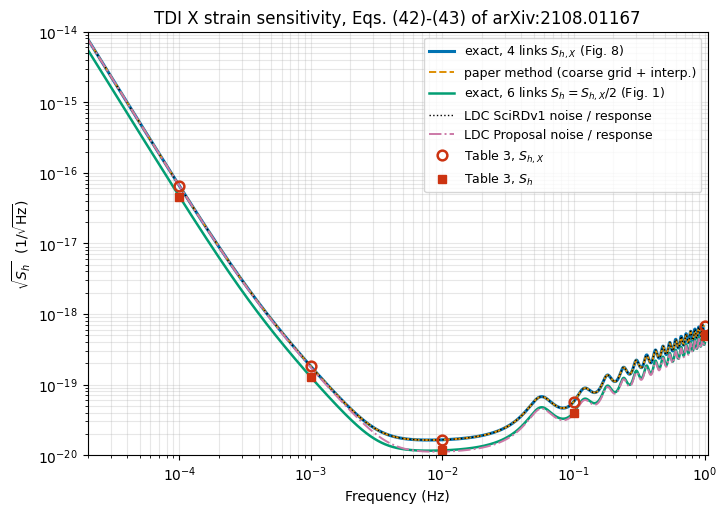

In [7]:
# exact sensitivity on the paper's evaluation grid vs their coarse-grid interpolation
Sh_exact = Sh_X(fr, sky_averaged_antenna_power(fr, "X", integrator="leggauss"))

# LDC noise models: sensitivity = channel noise PSD / channel response (4 links, X)
from ldc.lisa.noise import get_noise_model
from fast_lisa_subtraction.simulation.tdi import Sn
Sh_ldc = {name: Sn(fr, get_noise_model(name, fr).psd(fr, option="X", tdi2=True), channel="X", tdi2=True)
          for name in ["Proposal", "SciRDv1"]}

# Table 3 also tabulates the 6-link sensitivity S_h = S_h,X / 2 (Eq. 43), plotted in Fig. 1
table3_6link = {1e-4: 2.113678e-33, 1e-3: 1.633019e-38, 1e-2: 1.359556e-40, 1e-1: 1.609385e-39, 1.0: 2.299120e-37}

plt.figure(figsize=(8, 5.5))
plt.loglog(fr, np.sqrt(Sh_exact), color="#0173B2", lw=2.2, label=r"exact, 4 links $S_{h,X}$ (Fig. 8)")
plt.loglog(fr, np.sqrt(Sh_grid), color="#DE8F05", lw=1.4, ls="--", label="paper method (coarse grid + interp.)")
plt.loglog(fr, np.sqrt(Sh_exact/2), color="#029E73", lw=1.8, label=r"exact, 6 links $S_h = S_{h,X}/2$ (Fig. 1)")
plt.loglog(fr, np.sqrt(Sh_ldc["SciRDv1"]), color="k", lw=1.0, ls=":", label="LDC SciRDv1 noise / response")
plt.loglog(fr, np.sqrt(Sh_ldc["Proposal"]), color="#CC79A7", lw=1.4, ls="-.", label="LDC Proposal noise / response")
f3 = np.array(list(table3)); v3 = np.array(list(table3.values()))
plt.loglog(f3, np.sqrt(v3), "o", color="#CC3311", ms=7, mfc="none", mew=1.8, label=r"Table 3, $S_{h,X}$")
f6 = np.array(list(table3_6link)); v6 = np.array(list(table3_6link.values()))
plt.loglog(f6, np.sqrt(v6), "s", color="#CC3311", ms=6, label=r"Table 3, $S_h$")
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\sqrt{S_h}$  $(1/\sqrt{\rm Hz})$")
plt.xlim(2e-5, 1.05)
plt.ylim(1e-20, 1e-14)
plt.legend(fontsize=9)
plt.grid(alpha=0.3, which="both")
plt.title("TDI X strain sensitivity, Eqs. (42)-(43) of arXiv:2108.01167")
plt.show()